In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pickle
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cf
from datetime import date, datetime, timedelta
import xarray as xr
import netCDF4 as nc
from utils.u_interpolate_small import regrid_irregular_quick
from utils import u_interpolate_small as uint
#from ndays import numOfDays
import glob
import calendar
import os
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix
import math
import time
from utils.netncc_functions import FSS_accuracy_metric_gpu, FSS_loss_gpu, create_mean_filter, select_model_order, plot_maps_colorbar
from utils.plot_functions import plot_maps_colorbar, plot_maps_colorbar_lsta
from utils.netncc_classes import ConvLayer, netncc, XarrayUNetDataset, evalUNetDataset
from scipy.ndimage import uniform_filter


/home/jawahm/miniforge3/envs/coreDL_gpu/lib/python3.14/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 803: system has unsupported display driver / cuda driver combination (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
# Define domain and time period
# date is supposed to change automatically
current_date = '202601191400'
#--------------------------------
current_year = current_date[0:4]
current_month = current_date[4:6]
current_day = current_date[6:8]

In [3]:
domains =['WA','SA','EA']  # donot change the order as it affects the merging of domains into one image
device = 'cpu' #torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# TIR data dir
dir_name = '/prj/nflics/real_time_data/'+current_year+'/'

###### Define input shape
image_height= 1024 #lat
image_width= image_height #lon
in_channels = 3
out_channels = 1
start_year = '2004'
end_year = '2023'
leadtimes= [1,2,3,4,5,6]

# grid
resolution = 0.05
start_lat = -36.50 #
end_lat = 27.95  #
start_lon = -20.05 #
end_lon = 50.75 #

reg_lat_PA = np.round(np.arange(start_lat, end_lat, resolution),2)
reg_lon_PA = np.round(np.arange(start_lon, end_lon, resolution),2) 


In [4]:
# select files for input
current_date_int = datetime.strptime(current_date, '%Y%m%d%H%M')
to_date=datetime.strptime(str(current_date), '%Y%m%d%H%M')
to_minus_1hr_date=current_date_int-timedelta(hours=1)
to_minus_1hr_date= to_minus_1hr_date.strftime('%Y%m%d%H%M')
to_minus_2hr_date=current_date_int-timedelta(hours=2)
to_minus_2hr_date= to_minus_2hr_date.strftime('%Y%m%d%H%M')

dates_of_interest = [to_minus_2hr_date,to_minus_1hr_date,str(current_date)]
    

# list of files to be read
list_of_files = []                
for l in range(0,len(dates_of_interest),1):
    dates_of_interest_curr = dates_of_interest[l]
    list_of_files.append(dir_name+dates_of_interest_curr[4:6]+'/'+dates_of_interest_curr[6:8]+'/IR_108_BT_'+dates_of_interest_curr[0:4]+dates_of_interest_curr[4:6]+dates_of_interest_curr[6:8]+'_'+dates_of_interest_curr[8:]+'_eumdat.nc')

# check for to-2 file
if os.path.exists(list_of_files[0]) == False:
    to2_date = dates_of_interest[0]
    dir_name = '/prj/nflics/real_time_data/'+current_year+'/'+to2_date[4:6]+'/'+to2_date[6:8]+'/' 
    all_file_names = sorted(glob.glob(dir_name+"IR*.nc"));  #
    latest_to2_file = all_file_names[-4*2] 
   
    # check time between files 
    to_2_date=latest_to2_file[-23:-15]+latest_to2_file[-14:-10]
    to_2_datetime=datetime.strptime(str(int(to_2_date)), '%Y%m%d%H%M')
    time_difference = to_date-to_2_datetime    
    if time_difference< timedelta(hours=4.1): ###### IMPORTANT#####
        list_of_files[0]=latest_to2_file
        list_of_files[1]=all_file_names[-4]
    else:
        list_of_files[0]=list_of_files[2]
        list_of_files[1]=list_of_files[2]   
    


In [5]:
def predict_for_region(domain, to_date, dates_of_interest, list_of_files,leadtimes):
    # hardcoded for now
    image_height= 1024 #lat
    image_width= image_height #lon
    in_channels = 3
    out_channels = 1
    start_year = '2004'
    end_year = '2023'
    t = 3 #prior hours for prediction
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
 
    ###
    if domain=='WA':
        moi = 'JAS'
        end_lat = 27.95  #
        start_lon = -20.05 #
    
    elif domain=='SA':
        moi = 'DJF'
        end_lat = 14.7  #
        start_lon = -0.4 #
    
    elif domain== 'EA':
        moi = 'MAM'
        end_lat = 27.95  #
        start_lon = -0.4 #
    
  
    # load indices for domain and corresponding PA indices
    with open('utils/'+domain+'_regridding_weights_TIR_0p05.pkl', 'rb') as file:
            inds, weights, shape = pickle.load(file) 
    with open('utils/'+domain+'_regridding_weights_TIR_0p05_PA.pkl', 'rb') as file:
            inds_pa, weights_pa, shape_pa= pickle.load(file) 
    
    # read input for prediction
    regridded_tir = np.zeros((t,image_height,image_height),dtype=float) 
    
    # read in tir data
    for l in range(0,len(list_of_files),1): 
        tir_filename = list_of_files[l]
        if os.path.exists(tir_filename):
            ds = xr.open_dataset(tir_filename).squeeze() 
            tir_temp =  ds['ir108_bt'].values  #
            regridded_tir[l,:,:] = uint.interpolate_data(tir_temp, inds, weights, shape)  # interpolation using saved weights for MSG TIR
           
        
    # input data
    ind_tir = np.where(regridded_tir>-0.01)
    regridded_tir[ind_tir] = 0
    regridded_tir[np.isnan(regridded_tir)] = 0
    regridded_tir[regridded_tir<-110] = 0 #-110
    x_pred = np.round(regridded_tir/-110,4)
    test_image= torch.tensor(x_pred.astype(np.float32))
    test_image = test_image.unsqueeze(0)   # Add
    
    
    # predict for all leadtimes
    filtered_image=[]
    actual_cores=[]
    
    for leadtime in leadtimes:
        # read in model
        modelFile= 'trained_models/'+domain+'/'+domain+'_'+moi+'_2004_to_2023_'+str(leadtime)+'hr_using_1hr_0p05deg.pth'
        unet_model = netncc()# Training parameters
        unet_model = nn.DataParallel(unet_model)
        unet_model = unet_model.to(device)
        unet_model.load_state_dict(torch.load(modelFile,map_location=device))
        # Set the model to evaluation mode
        unet_model.eval()
        
        prediction_time = int((to_date+timedelta(hours=leadtime)).strftime('%Y%m%d%H%M'))  ###### IMPORTANT#####
        # time of day predicted
        time_of_day_tr= np.zeros((1,image_height, image_width))
        time_of_day = float(str(prediction_time)[8:])/2345
        time_of_day_tr[:,:,:]=round(np.sin(time_of_day*math.pi),2)
        tod = torch.tensor(time_of_day_tr.astype(np.float32))
        tod = tod.unsqueeze(0)   # Add batch dimension
    
        # predict for one day
        with torch.no_grad():
            predicted_core = unet_model(test_image,tod)
        
        predicted_core = torch.nan_to_num(predicted_core, nan=0.0, posinf=0, neginf=0).squeeze()
        filtered_image.append(torch.Tensor.numpy(predicted_core)) # in case filtering needed later on

    filtered_image = np.array(filtered_image)
    
    regrid_nowcasts = uint.interpolate_data(filtered_image, inds_pa, weights_pa, shape_pa)  # interpolation using saved weights for MSG TIR
    
    return regrid_nowcasts 

In [6]:
# predict for all domains
all_domain_nowcasts = np.zeros((len(domains), len(leadtimes), len(reg_lat_PA), len(reg_lon_PA)))
panAfrica_nowcast =  np.zeros((len(leadtimes), len(reg_lat_PA), len(reg_lon_PA)))

for i in range(len(domains)):
    all_domain_nowcasts[i,:,:,:] = predict_for_region(domains[i],to_date,dates_of_interest,list_of_files,leadtimes)

# merge into one map for each leadtime    
domain_order =  select_model_order(int(current_month))
for d in [2,1,0]:
    domain_image = all_domain_nowcasts[domain_order[d],:,:,:].squeeze()
    ind_ok = ~np.isnan(domain_image)
    panAfrica_nowcast[ind_ok] = domain_image[ind_ok]
    del ind_ok
    
panAfrica_nowcast[np.isnan(panAfrica_nowcast)]=0
smoothed_nowcasts = uniform_filter(panAfrica_nowcast, size=3, mode='reflect')


In [18]:
panAfrica_nowcast.shape

(6, 1289, 1416)

In [10]:
'''
    
# get native MSG grid (core)
#coords_filename = glob.glob('/prj/Africa_cloud/geoloc/*.npz')[0]  # this is /prj/Africa_cloud/geoloc/*.npz on the Linux system
#msg_latlon = np.load(coords_filename)
#mlon = msg_latlon['lon']
#mlat = msg_latlon['lat']
# domain only coords
#reg_lat = np.arange(end_lat-resolution*image_height, end_lat, resolution)
#reg_lon = np.arange(start_lon, start_lon+resolution*(image_height), resolution) 
  
resolution = 0.05
image_height= 1024 #lat
image_width= image_height #lon
end_lat = 27.95  #
start_lon = -0.4 #
reg_lat = np.arange(end_lat-resolution*image_height, end_lat, resolution)
reg_lon = np.arange(start_lon, start_lon+resolution*(image_height), resolution) 

inds_pa, weights_pa, shape_pa = uint.interpolation_weights(reg_lon, reg_lat, reg_lon_PA, reg_lat_PA) # save weights for continuous use - MSG interpolation on regular. 

with open('utils/'+domain+'_regridding_weights_TIR_0p05_PA.pkl', 'wb') as file:
    pickle.dump([inds_pa, weights_pa, shape_pa],file) 

regrid_nowcasts = uint.interpolate_data(filtered_image, inds_pa, weights_pa, shape_pa)  # interpolation using saved weights for MSG TIR

'''

In [10]:
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_maps(ax, lon, lat, data,levels_custom,plot_map):
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,linewidth=1, color='gray', alpha=0.75, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    #gl.xlocator = mticker.FixedLocator([30, 35])
    #gl.ylocator = mticker.FixedLocator([-15, -18])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'gray'}
    gl.ylabel_style = {'size': 10, 'color': 'gray'}
    #ax.set_ylim(min_lat, max_lat)
    #ax.set_xlim(min_lon, max_lon)
    # ax.set_title(title)
    # Countries
    ax.coastlines()   ## adds coastlines
    ax.add_feature(cartopy.feature.BORDERS, linestyle='--'); # adds country borders
    m=ax.contourf(lon, lat, data, transform=ccrs.PlateCarree(), levels=levels_custom,cmap=plot_map)  # this is the actual plot

def plot_maps_colorbar(ax, lon, lat, data,levels_custom,plot_label):
    m=ax.contourf(lon, lat, data, transform=ccrs.PlateCarree(), levels=levels_custom,cmap='jet')  # this is the actual plot
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,linewidth=1, color='gray', alpha=0.75, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    #gl.xlocator = mticker.FixedLocator([20, 25, 30, 35, 40])
    #gl.ylocator = mticker.FixedLocator([0, -5, -10, -15, -20, -25])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 7, 'color': 'gray'}
    gl.ylabel_style = {'size': 7, 'color': 'gray'}
    # ax.set_title(title)
    # Countries
    ax.coastlines()   ## adds coastlines
    ax.add_feature(cartopy.feature.BORDERS, linestyle='--',color='white'); # adds country borders
    cbar = plt.colorbar(m,fraction=0.03)  # adds colorbar
    cbar.set_label(plot_label)  

In [19]:
regrid_nowcasts = smoothed_nowcasts   #all_domain_nowcasts[2].squeeze()
regrid_nowcasts.shape

(6, 1289, 1416)

202601191400


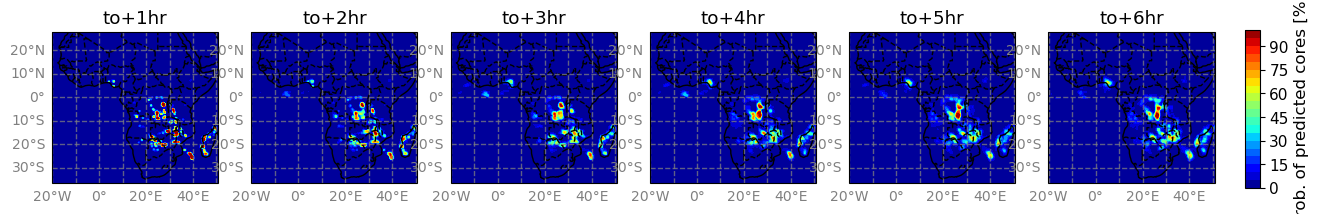

In [20]:
#data= np.squeeze(x_pred[:,:,:])
data1= [
    np.squeeze(regrid_nowcasts[0]),
    np.squeeze(regrid_nowcasts[1]),
    np.squeeze(regrid_nowcasts[2]),
    np.squeeze(regrid_nowcasts[3]),
    np.squeeze(regrid_nowcasts[4]),
    np.squeeze(regrid_nowcasts[5])]

#data1=np.round(data1,2)

titles = ['TIR at to-2hr','TIR at to-1hr','TIR at to ('+current_date+')']
pc_title=['to+1hr','to+2hr','to+3hr','to+4hr','to+5hr','to+6hr']
#pc_title=['Predicted cores at to+1hr','Predicted cores at to+2hr','Predicted cores at to+4hr','Predicted cores at to+6hr']
#ac_title=['Actual cores at to+1hr','Predicted cores at to+2hr','Predicted cores at to+4hr','Predicted cores at to+6hr']

levels_custom=np.arange(0,1.01,0.05)
labels=['Normalized abs. TIR <0oC', 'Prob. of predicted cores [%]','Actual cores [-]']

plt.rcParams.update({'font.size': 11})

fig, axes = plt.subplots(1, 6, figsize=(15, 7), subplot_kw={'projection':ccrs.PlateCarree()})



for idx, ax in enumerate(axes):
    if idx<5:
        plot_maps(ax, reg_lon_PA, reg_lat_PA, data1[idx]*100,levels_custom= levels_custom*100,plot_map='jet')
        ax.set_title(pc_title[idx])
    else:
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,linewidth=1, color='gray', alpha=0.75, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        #gl.xlocator = mticker.FixedLocator([30, 35])
        #gl.ylocator = mticker.FixedLocator([-15, -18])
        #gl.xformatter = LONGITUDE_FORMATTER
        #gl.yformatter = LATITUDE_FORMATTER
        gl.xlabel_style = {'size': 10, 'color': 'gray'}
        gl.ylabel_style = {'size': 10, 'color': 'gray'}
        #ax.set_ylim(min_lat, max_lat)
        #ax.set_xlim(min_lon, max_lon)
        # Countries
        ax.coastlines()   ## adds coastlines
        ax.add_feature(cartopy.feature.BORDERS, linestyle='--'); # adds country borders
        m=ax.contourf(reg_lon_PA, reg_lat_PA, data1[idx]*100, transform=ccrs.PlateCarree(), levels=levels_custom*100,cmap='jet')  # this is the actual plot
        ax.set_title(pc_title[idx])
        # Create a colorbar that spans all subplots
        fig.subplots_adjust(right=0.9)
        cbar_ax = fig.add_axes([0.92, 0.38, 0.01, 0.225])
        cbar = fig.colorbar(m, cax=cbar_ax)
        # Set the colorbar label
        cbar.set_label(labels[1],fontsize=12)
        


#plt.savefig('../../figures/testbed2.png', dpi=400)

# Print information and display the figure.
print(current_date)
#plt.show()

/home/jawahm/miniforge3/envs/coreDL_gpu/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


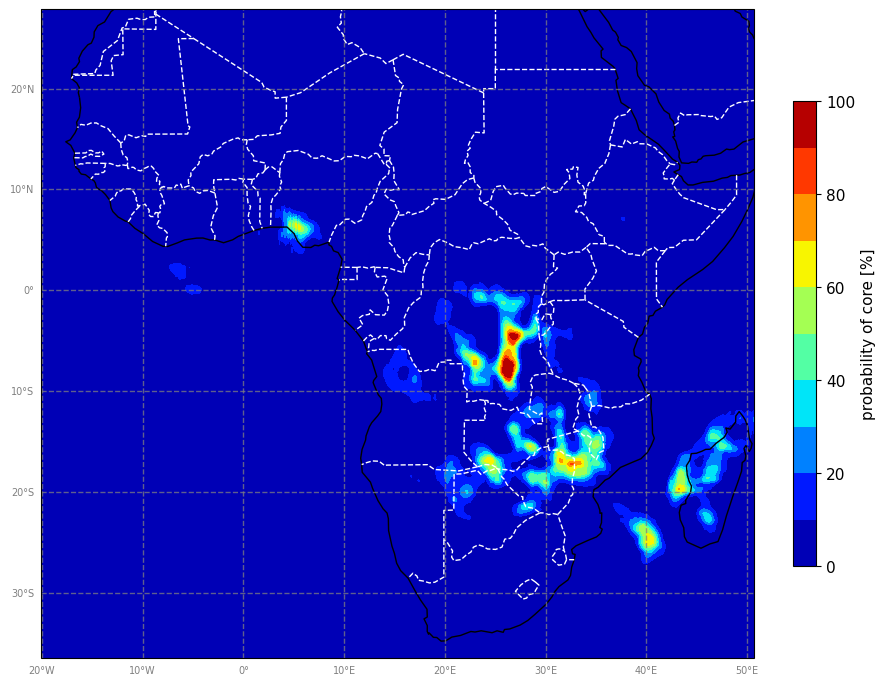

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection':ccrs.PlateCarree()})

plot_maps_colorbar(ax, reg_lon_PA, reg_lat_PA, data1[5]*100 ,levels_custom= np.arange(0,101,10),plot_label='probability of core [%]')
#plot_maps_colorbar(ax, reg_lon, reg_lat, filtered_image[4]*100 ,levels_custom= np.arange(0,101,10),plot_label='probability of core [%]')
